In [49]:
import os
import h5py
from torch_brain.data import Data
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np
from scipy.signal import spectrogram

In [2]:
# BIDS_ROOT = ("/capstor/scratch/cscs/davalos/data/processed/omni_ieeg")
# H5_FILENAME = "sub-openieegDetroit078_ses-01_task-sleep.h5"
BIDS_ROOT = ("/Users/avalos/Documents/Programming/neurosoft_epilepsy/data/processed/omni_ieeg")
H5_FILENAME="sub-openieegDetroit006_ses-01_task-sleep.h5"

### 1. Load .h5 file

In [3]:
with h5py.File(os.path.join(BIDS_ROOT, H5_FILENAME), "r") as f:
    data = Data.from_hdf5(f, lazy=False)

    print("Fields in data:")
    for key in data.keys():
        print("   - ", key)

Fields in data:
   -  annotations
   -  brainset
   -  channels
   -  device
   -  ieeg
   -  session
   -  subject
   -  dataset_name
   -  outcome
   -  split
   -  task_name


In [4]:
print(data.annotations)

Interval(
  start=[332],
  end=[332],
  artifact=[332],
  channel=[332],
  description=[332],
  detector=[332],
  method=[332],
  spike=[332]
)


In [6]:
data.ieeg

RegularTimeSeries(
  signal=[304000, 100]
)

### 2. Channels info

In [7]:
print("Channel names: ", data.channels.id[1:5])
print("Channel types: ", data.channels.type[1:5])

Channel names:  ['A2-AV' 'A3-AV' 'A4-AV' 'A5-AV']
Channel types:  ['eeg' 'eeg' 'eeg' 'eeg']


In [17]:
ch_names=data.channels.id
ch_types=data.channels.type
start_time=0
signal = data.ieeg.signal # ecog
timestamps = data.ieeg.timestamps # ecog
timestamps
len(ch_names)

100

/var/folders/c1/5p016ykn6l74j06yf7xtfw500000gq/T/ipykernel_36986/1935738969.py:16: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


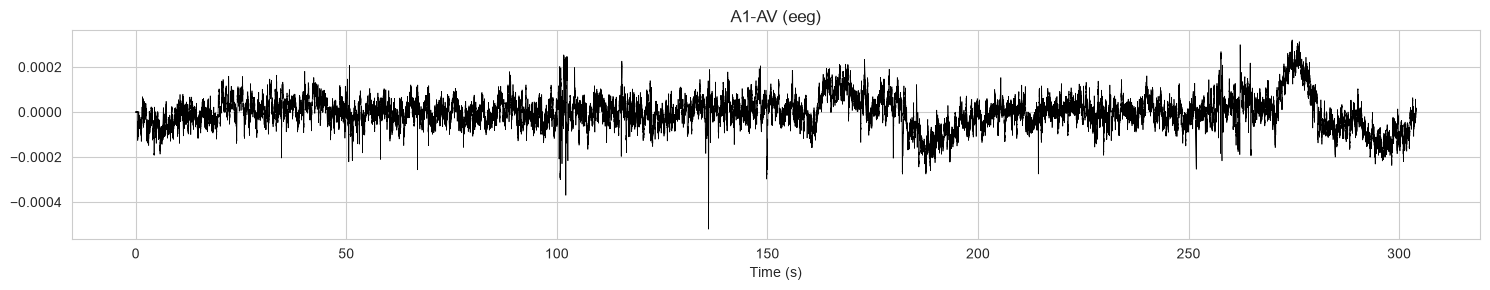

In [20]:
def plot_channel(signal, timestamps, ch_names, ch_types, channel_idx=0, start_time=0, end_time=None, figsize=(15, 3)):
    if end_time is None:
        end_time = timestamps[-1]
    keep = (timestamps >= start_time) & (timestamps <= end_time)

    fig, ax = plt.subplots(figsize=figsize)
    ax.plot(timestamps[keep], signal[keep, channel_idx], color="black", linewidth=0.5)
    ax.set_xlabel("Time (s)")
    ax.set_title(f"{ch_names[channel_idx]} ({ch_types[channel_idx]})")
    fig.tight_layout()
    return fig


fig = plot_channel(signal, timestamps, ch_names, ch_types, channel_idx=0, start_time=start_time)
fig.show()

/var/folders/c1/5p016ykn6l74j06yf7xtfw500000gq/T/ipykernel_36986/2873590893.py:29: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


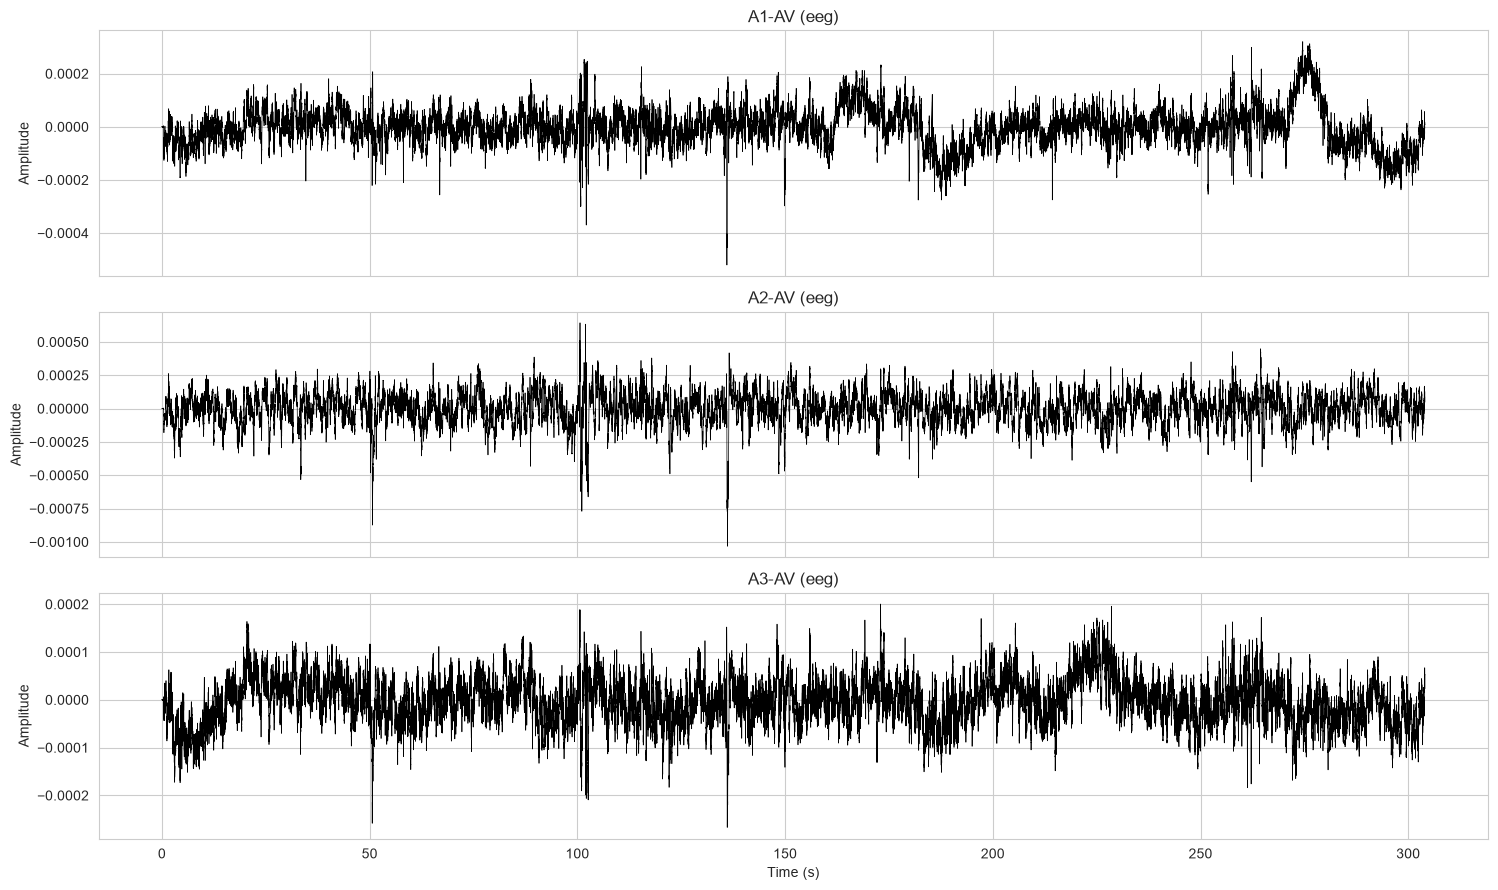

In [30]:
def plot_channels(signal, timestamps, ch_names, ch_types, channel_indices=[0,1,2], start_time=0, end_time=None, figsize=(15, 3)):

    n = len(channel_indices)

    if end_time is None:
        end_time = timestamps[-1]
    keep = (timestamps >= start_time) & (timestamps <= end_time)

    fig, axes = plt.subplots(
        n, 1,
        figsize=(figsize[0], figsize[1] * n),
        sharex=True
    )

    if n == 1:
        axes = [axes]  # make it iterable when there's only one channel

    for ax, ch_idx in zip(axes, channel_indices):
        ax.plot(timestamps[keep], signal[keep, ch_idx], color="black", linewidth=0.5)
        ax.set_title(f"{ch_names[ch_idx]} ({ch_types[ch_idx]})")
        ax.set_ylabel("Amplitude")

    axes[-1].set_xlabel("Time (s)")
    fig.tight_layout()
    return fig


fig = plot_channels(signal, timestamps, ch_names, ch_types, channel_indices=np.arange(len(ch_names[0:3])), start_time=0, end_time=None, figsize=(15, 3))
fig.show()


### 3. iEEG data visualization

In [ ]:
def plot_channel_with_hfo_events(
    signal, timestamps, ch_names, ch_types, annotations,
    channel_idx=0, start_time=0, end_time=None, figsize=(15, 3),
):
    """Plot one channel's raw signal with its doctor-annotated HFO events shaded.

    `annotations` is `data.annotations` after merging in HFO events (see
    `foundry.data.pipelines.omni_ieeg._build_annotations`) -- each event has a
    `channel`, `start`/`end` (seconds) and an `artifact` flag (1 = doctor
    marked it as an artifact, not a true HFO).
    """
    fig = plot_channel(signal, timestamps, ch_names, ch_types, channel_idx, start_time, end_time, figsize)
    ax = fig.axes[0]

    ch_name = ch_names[channel_idx]
    on_channel = annotations.channel.astype(str) == ch_name

    legend_handles = {}
    for ev_start, ev_end, artifact in zip(
        annotations.start[on_channel], annotations.end[on_channel], annotations.artifact[on_channel]
    ):
        if ev_start > (end_time if end_time is not None else timestamps[-1]) or ev_end < start_time:
            continue
        label = "HFO (artifact)" if artifact == 1 else "HFO"
        color = "red" if artifact == 1 else "orange"
        ax.axvspan(ev_start, ev_end, color=color, alpha=0.3, lw=0)
        legend_handles[label] = Patch(facecolor=color, alpha=0.3, label=label)

    if legend_handles:
        ax.legend(handles=list(legend_handles.values()), loc="upper right")
    return fig


In [ ]:
def plot_channel_spectrogram(
    signal, timestamps, ch_names, ch_types, channel_idx=0,
    start_time=0, end_time=None, window_ms=600, step_ms=300, figsize=(15, 3),
):
    """Plot a spectrogram of one channel using a sliding window.

    `window_ms` is the length of each FFT segment; `step_ms` is how far the
    window slides between segments (so overlap = window_ms - step_ms).
    """
    if end_time is None:
        end_time = timestamps[-1]
    keep = (timestamps >= start_time) & (timestamps <= end_time)
    trace = signal[keep, channel_idx]
    t = timestamps[keep]

    sfreq = 1 / np.median(np.diff(t))
    nperseg = int(window_ms / 1000 * sfreq)
    noverlap = nperseg - int(step_ms / 1000 * sfreq)

    freqs, times, sxx = spectrogram(trace, fs=sfreq, nperseg=nperseg, noverlap=noverlap)

    fig, ax = plt.subplots(figsize=figsize)
    mesh = ax.pcolormesh(t[0] + times, freqs, 10 * np.log10(sxx + 1e-12), shading="gouraud")
    fig.colorbar(mesh, ax=ax, label="Power (dB)")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Frequency (Hz)")
    ax.set_title(f"{ch_names[channel_idx]} ({ch_types[channel_idx]}) spectrogram")
    fig.tight_layout()
    return fig

In [59]:
ch_names

array(['A1-AV', 'A2-AV', 'A3-AV', 'A4-AV', 'A5-AV', 'A6-AV', 'A7-AV',
       'A8-AV', 'A9-AV', 'A10-AV', 'A11-AV', 'A12-AV', 'A13-AV', 'A14-AV',
       'A15-AV', 'A16-AV', 'A17-AV', 'A18-AV', 'A19-AV', 'A20-AV',
       'A21-AV', 'A22-AV', 'A23-AV', 'A24-AV', 'A25-AV', 'A26-AV',
       'A27-AV', 'A28-AV', 'A29-AV', 'A30-AV', 'A31-AV', 'A32-AV',
       'A33-AV', 'A34-AV', 'A35-AV', 'A36-AV', 'A37-AV', 'A38-AV',
       'A39-AV', 'A40-AV', 'A41-AV', 'A42-AV', 'A43-AV', 'A44-AV',
       'A45-AV', 'A46-AV', 'A47-AV', 'A48-AV', 'A49-AV', 'A50-AV',
       'A51-AV', 'A52-AV', 'A53-AV', 'A54-AV', 'A55-AV', 'A56-AV',
       'A57-AV', 'A58-AV', 'A59-AV', 'A60-AV', 'A61-AV', 'A62-AV',
       'A63-AV', 'A64-AV', 'B1-AV', 'B2-AV', 'B3-AV', 'B4-AV', 'B5-AV',
       'B6-AV', 'B7-AV', 'B8-AV', 'B9-AV', 'B10-AV', 'B11-AV', 'B12-AV',
       'B13-AV', 'B14-AV', 'B15-AV', 'B16-AV', 'B17-AV', 'B18-AV',
       'B19-AV', 'B20-AV', 'B21-AV', 'B22-AV', 'B23-AV', 'B24-AV',
       'B25-AV', 'B26-AV', 'B27-AV', 'B2

/var/folders/c1/5p016ykn6l74j06yf7xtfw500000gq/T/ipykernel_36986/1837334236.py:6: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


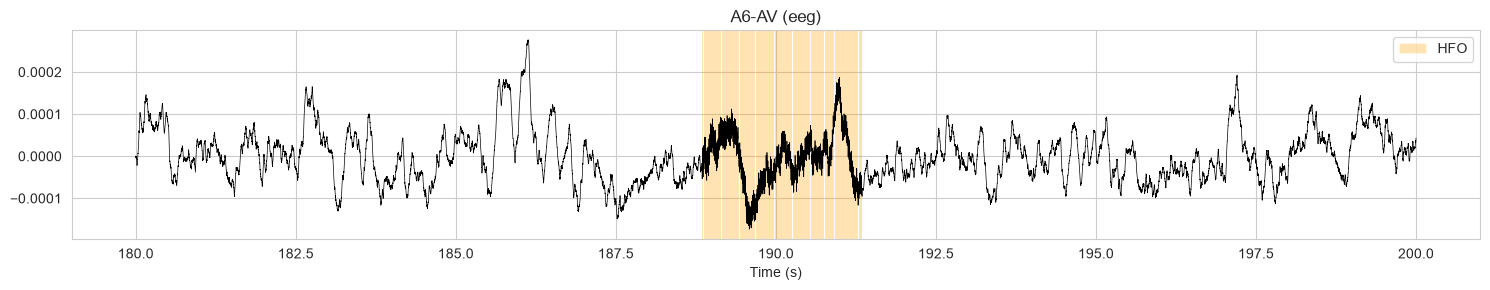

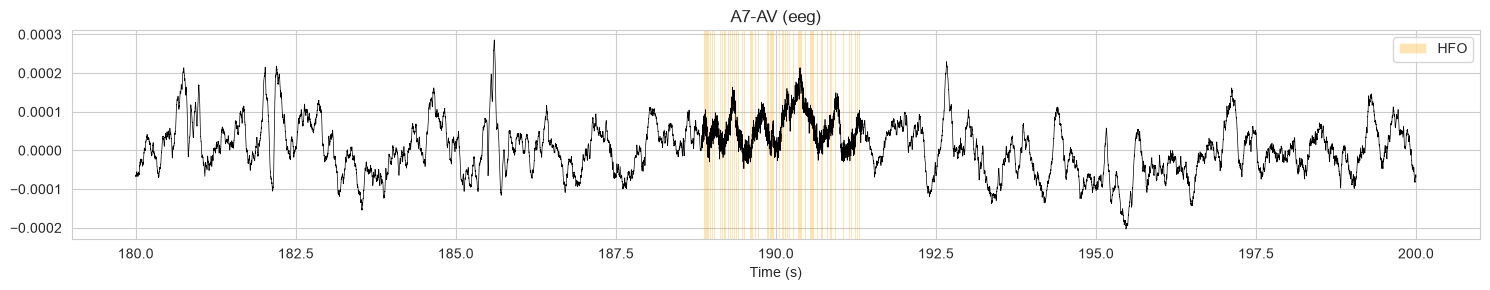

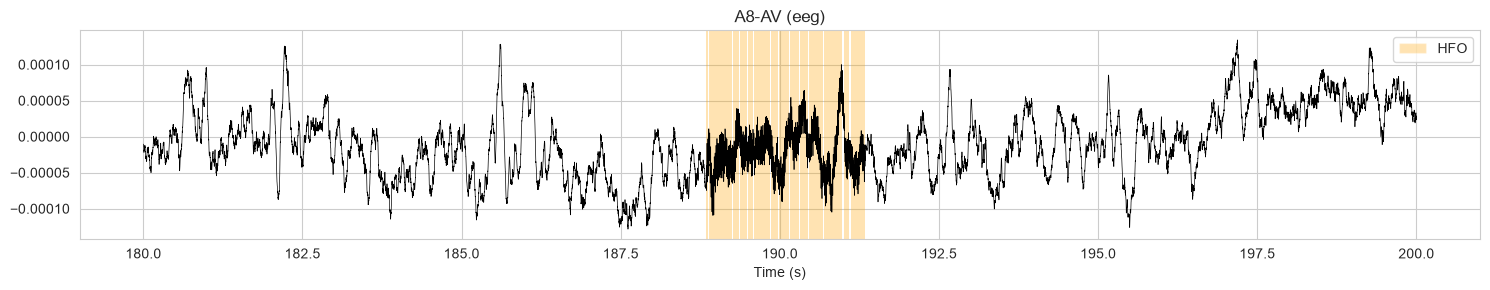

In [62]:
for ch_nbr in np.arange(5,8):
    fig = plot_channel_with_hfo_events(
        signal, timestamps, ch_names, ch_types, data.annotations,
        channel_idx=ch_nbr,start_time=180, end_time=200,
    )
    fig.show()

/var/folders/c1/5p016ykn6l74j06yf7xtfw500000gq/T/ipykernel_36986/3592610184.py:3: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


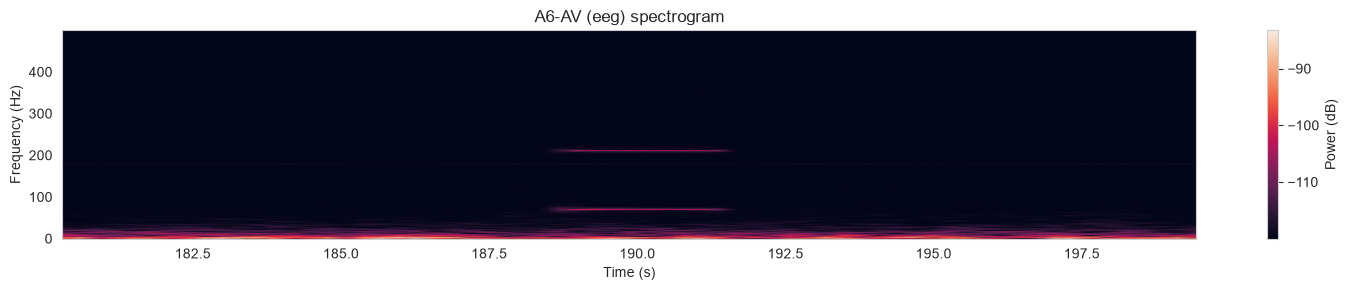

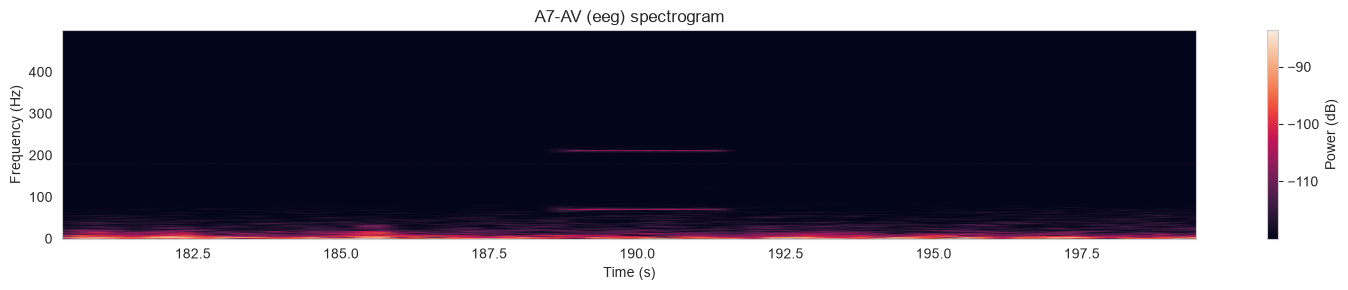

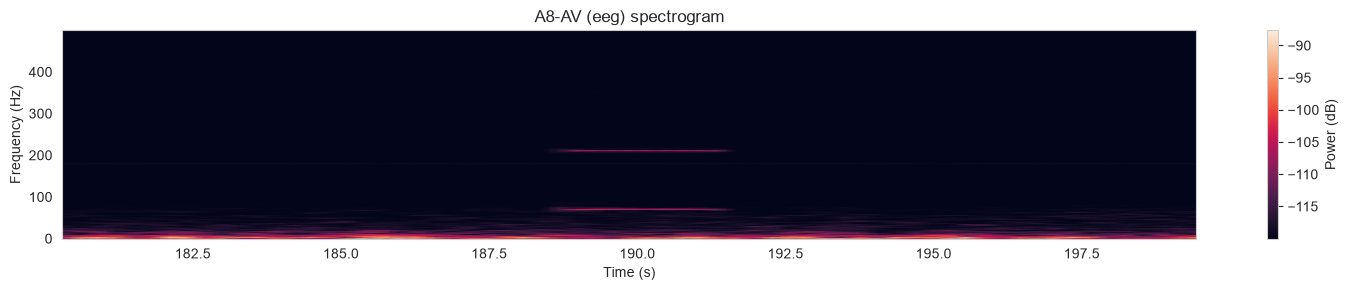

In [61]:
for ch_nbr in np.arange(5,8):
    fig = plot_channel_spectrogram(signal, timestamps, ch_names, ch_types, channel_idx=ch_nbr, start_time=180, end_time=200)
    fig.show()

In [38]:
ch_names[0]

np.str_('A1-AV')

In [47]:
on_channel = 5
data.annotations.start[on_channel], data.annotations.end[on_channel], data.annotations.artifact[on_channel]

(np.float64(189.166), np.float64(189.214), np.int8(0))